## Advanced Multi-Source Data Pipeline: CoinGecko API + Web Scraping → Data Cleaning →Exploratory Data Analysis

#### Project Objectives
• Collect data from CoinGecko API (cryptocurrency market data)
• Scrape product data from Books to Scrape website
• Perform advanced data cleaning on both datasets
• Conduct comprehensive EDA
• Generate insights and visualizations
• Create a reusable cleaning + EDA framework

In [169]:
#Import libraries
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

In [170]:
#CoinGecko Dataset
#Collect Crypto data
url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 100,
    "page": 1,
    "sparkline": "false",
    "price_change_percentage": "24h,7d"}

r = requests.get(url, params=params)

crypto = pd.DataFrame(r.json())

crypto.head()



,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated,price_change_percentage_24h_in_currency,price_change_percentage_7d_in_currency
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,79922.00,1604828890224,1,1604836402809,1.882957e+10,80147.00,...,126080.00,-36.61036,2025-10-06T10:57:42.000Z,67.810000,1.177628e+05,2013-07-05T16:00:00.000Z,None,2026-09-06T01:32:20.000Z,0.29503,2.2
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2494.57,304387667887,2,304387667887,7.107570e+09,2491.92,...,4946.05,-49.56436,2025-08-24T11:21:03.000Z,0.432979,5.760416e+05,2015-10-19T16:00:00.000Z,"{'times': 40.74222399926413, 'currency': 'btc'...",2026-09-06T01:32:20.000Z,1.60608,1.4
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,1.00,183399738344,3,188866903417,3.944652e+10,1.00,...,1.32,-24.41628,2018-07-23T16:00:00.000Z,0.572521,7.467388e+01,2015-03-01T16:00:00.000Z,None,2026-09-06T01:32:20.000Z,-0.01275,0.0
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,765.29,101907199453,4,101907198719,2.227033e+09,779.70,...,1369.99,-44.13906,2025-10-13T00:41:24.000Z,0.039818,1.921885e+06,2017-10-18T16:00:00.000Z,None,2026-09-06T01:32:20.000Z,5.79105,10.8
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.42,88930977448,5,141714714655,1.499235e+09,1.43,...,3.65,-61.12806,2025-07-17T19:40:53.000Z,0.002686,5.266652e+04,2014-05-21T16:00:00.000Z,None,2026-09-06T01:32:20.000Z,1.14919,1.4


In [171]:
#Select useful columns
crypto = crypto[[
    "id",
    "symbol",
    "name",
    "current_price",
    "market_cap",
    "total_volume",
    "circulating_supply",
    "total_supply",
    "max_supply",
    "price_change_percentage_24h_in_currency",
    "price_change_percentage_7d_in_currency",
    "last_updated"]]

crypto.head()

,id,symbol,name,current_price,market_cap,total_volume,circulating_supply,total_supply,max_supply,price_change_percentage_24h_in_currency,price_change_percentage_7d_in_currency,last_updated
0,bitcoin,btc,Bitcoin,79922.00,1604828890224,1.882957e+10,2.008016e+07,2.008028e+07,2.100000e+07,0.29503,2.2,2026-09-06T01:32:20.000Z
1,ethereum,eth,Ethereum,2494.57,304387667887,7.107570e+09,1.220209e+08,1.220209e+08,NaN,1.60608,1.4,2026-09-06T01:32:20.000Z
2,tether,usdt,Tether,1.00,183399738344,3.944652e+10,1.833924e+11,1.888593e+11,NaN,-0.01275,0.0,2026-09-06T01:32:20.000Z
3,binancecoin,bnb,BNB,765.29,101907199453,2.227033e+09,1.331619e+08,1.331619e+08,2.000000e+08,5.79105,10.8,2026-09-06T01:32:20.000Z
4,ripple,xrp,XRP,1.42,88930977448,1.499235e+09,6.274450e+10,9.998563e+10,1.000000e+11,1.14919,1.4,2026-09-06T01:32:20.000Z


In [172]:
#Initial inspection
print(crypto.shape)

crypto.info()

print(crypto.isnull().sum())

print("Duplicates:", crypto.duplicated().sum())

(100, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       100 non-null    object 
 1   symbol                                   100 non-null    object 
 2   name                                     100 non-null    object 
 3   current_price                            100 non-null    float64
 4   market_cap                               100 non-null    int64  
 5   total_volume                             100 non-null    float64
 6   circulating_supply                       100 non-null    float64
 7   total_supply                             100 non-null    float64
 8   max_supply                               54 non-null     float64
 9   price_change_percentage_24h_in_currency  100 non-null    float64
 10  price_change_percentage_7d_in_currency   

In [173]:
# Clean Crypto data
crypto = crypto.drop_duplicates(subset="id")

crypto["last_updated"] = pd.to_datetime(crypto["last_updated"])

numeric_cols = [
    "current_price",
    "market_cap",
    "total_volume",
    "circulating_supply",
    "total_supply",
    "max_supply",
    "price_change_percentage_24h_in_currency",
    "price_change_percentage_7d_in_currency"]

for col in numeric_cols:
    crypto[col] = pd.to_numeric(
        crypto[col],
        errors="coerce")

crypto = crypto[
    crypto["current_price"] > 0]

crypto["market_cap"] = crypto["market_cap"].fillna(
    crypto["market_cap"].median())

crypto["total_volume"] = crypto["total_volume"].fillna(
    crypto["total_volume"].median())

crypto.head()

,id,symbol,name,current_price,market_cap,total_volume,circulating_supply,total_supply,max_supply,price_change_percentage_24h_in_currency,price_change_percentage_7d_in_currency,last_updated
0,bitcoin,btc,Bitcoin,79922.00,1604828890224,1.882957e+10,2.008016e+07,2.008028e+07,2.100000e+07,0.29503,2.2,2026-09-06 01:32:20+00:00
1,ethereum,eth,Ethereum,2494.57,304387667887,7.107570e+09,1.220209e+08,1.220209e+08,NaN,1.60608,1.4,2026-09-06 01:32:20+00:00
2,tether,usdt,Tether,1.00,183399738344,3.944652e+10,1.833924e+11,1.888593e+11,NaN,-0.01275,0.0,2026-09-06 01:32:20+00:00
3,binancecoin,bnb,BNB,765.29,101907199453,2.227033e+09,1.331619e+08,1.331619e+08,2.000000e+08,5.79105,10.8,2026-09-06 01:32:20+00:00
4,ripple,xrp,XRP,1.42,88930977448,1.499235e+09,6.274450e+10,9.998563e+10,1.000000e+11,1.14919,1.4,2026-09-06 01:32:20+00:00


In [174]:
# Feature Engineering
# Market Cap Category
crypto["market_cap_category"] = pd.cut(
    crypto["market_cap"],
    bins=[0, 1e8, 1e9, 1e10, np.inf],
    labels=["Small", "Medium", "Large", "Mega"])

In [175]:
# Supply Ratio
crypto["supply_ratio"] = (crypto["circulating_supply"] /crypto["total_supply"])

In [176]:
# Volatility Score
crypto["volatility_score"] = (crypto["price_change_percentage_24h_in_currency"].abs()+
    crypto["price_change_percentage_7d_in_currency"].abs())

In [177]:
# Crypto Outlier Detection
#Isolation Forest
features = crypto[
    ["current_price", "market_cap", "total_volume"]].fillna(0)

model = IsolationForest(
    contamination=0.05,
    random_state=42)

crypto["outlier"] = model.fit_predict(features)

crypto["outlier"] = crypto["outlier"].map({1: "Normal",-1: "Outlier"})

crypto["outlier"].value_counts()

outlier
Normal     95
Outlier     5
Name: count, dtype: int64

In [178]:
# Books to Scrape
# Scrape Books data

import requests
import pandas as pd
from bs4 import BeautifulSoup

url = "https://books.toscrape.com/catalogue/page-1.html"

headers = {
    "User-Agent": "Mozilla/5.0"
}

r = requests.get(url, headers=headers, timeout=20)

print("Status:", r.status_code)

soup = BeautifulSoup(r.text, "html.parser")

items = soup.select("article.product_pod")

print("Books found:", len(items))

Status: 200
Books found: 20


In [179]:
books_data = []

for page in range(1, 51):

    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    r = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=20
    )

    soup = BeautifulSoup(r.text, "html.parser")

    for book in soup.select("article.product_pod"):

        title = book.h3.a["title"]

        price = book.select_one(".price_color").text

        rating = book.select_one(".star-rating")["class"][1]

        availability = book.select_one(
            ".availability"
        ).get_text(strip=True)

        books_data.append({
            "title": title,
            "price": price,
            "rating": rating,
            "availability": availability
        })

books = pd.DataFrame(books_data)

print("Shape:", books.shape)

books.head()

Shape: (1000, 4)


,title,price,rating,availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [180]:
# Clean Books data
# Convert price safely
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

books["price"] = (
    books["price"]
    .astype(str)
    .str.replace("£", "", regex=False)
    .str.replace("Â", "", regex=False)
)

books["price"] = pd.to_numeric(
    books["price"],
    errors="coerce"
)

books["rating"] = books["rating"].map(rating_map)

print(books.shape)
print(books.head())

(1000, 4)
                                   title  price  rating availability
0                   A Light in the Attic  51.77       3     In stock
1                     Tipping the Velvet  53.74       1     In stock
2                             Soumission  50.10       1     In stock
3                          Sharp Objects  47.82       4     In stock
4  Sapiens: A Brief History of Humankind  54.23       5     In stock


In [181]:
print("Shape:", books.shape)
print("Missing prices:", books["price"].isnull().sum())

Shape: (1000, 4)
Missing prices: 0


In [182]:
print(books.shape)
print(books.head())
print(books["price"].dtype)
print(books["price"].isnull().sum())

(1000, 4)
                                   title  price  rating availability
0                   A Light in the Attic  51.77       3     In stock
1                     Tipping the Velvet  53.74       1     In stock
2                             Soumission  50.10       1     In stock
3                          Sharp Objects  47.82       4     In stock
4  Sapiens: A Brief History of Humankind  54.23       5     In stock
float64
0


In [ ]:
# Book Feature Engineering
books["price_category"] = pd.cut(
    books["price"],
    bins=[0, 20, 40, np.inf],
    labels=["Low", "Medium", "High"])

books["rating_group"] = pd.cut(
    books["rating"],
    bins=[0, 2, 3, 5],
    labels=[
        "Low Rating",
        "Average Rating",
        "High Rating"])

books.head()

,title,price,rating,availability,price_category,rating_group
0,A Light in the Attic,51.77,3,In stock,High,Average Rating
1,Tipping the Velvet,53.74,1,In stock,High,Low Rating
2,Soumission,50.10,1,In stock,High,Low Rating
3,Sharp Objects,47.82,4,In stock,High,High Rating
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,High,High Rating


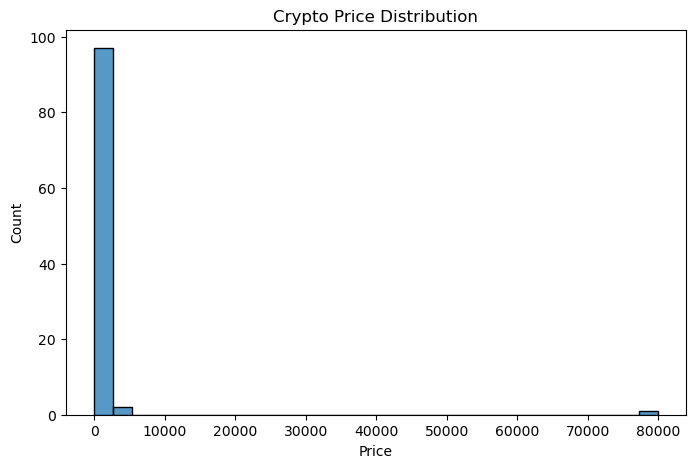

In [ ]:
# EDA
#Crypto Price Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    crypto["current_price"],
    bins=30)

plt.title("Crypto Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

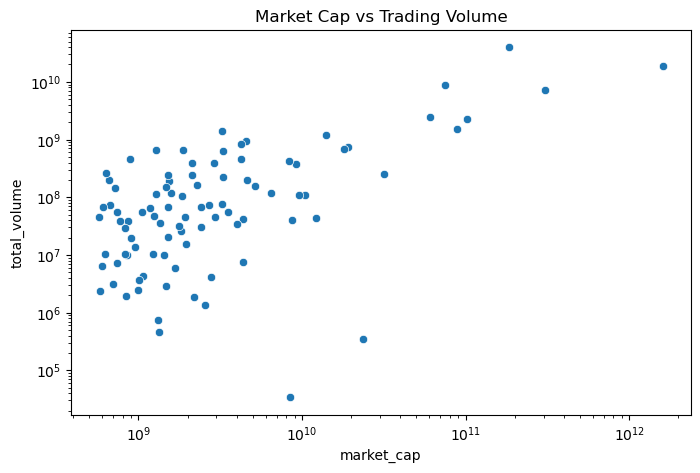

In [ ]:
# Crypto Market Cap vs Volume
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=crypto,
    x="market_cap",
    y="total_volume")

plt.xscale("log")
plt.yscale("log")

plt.title("Market Cap vs Trading Volume")

plt.show()

In [ ]:
# Highest Volatility Coins
crypto[[
        "name",
        "volatility_score"]].sort_values(
    "volatility_score",
    ascending=False).head(10)

,name,volatility_score
93,Pons,320.94292
64,Arbitrum,165.86945
22,Uniswap,74.92480
77,Dash,68.94905
89,PancakeSwap,44.41225
96,Curve DAO,37.25888
69,Lighter,33.20677
54,Pump.fun,30.93689
48,Ethena,27.84951
10,Zcash,27.55130


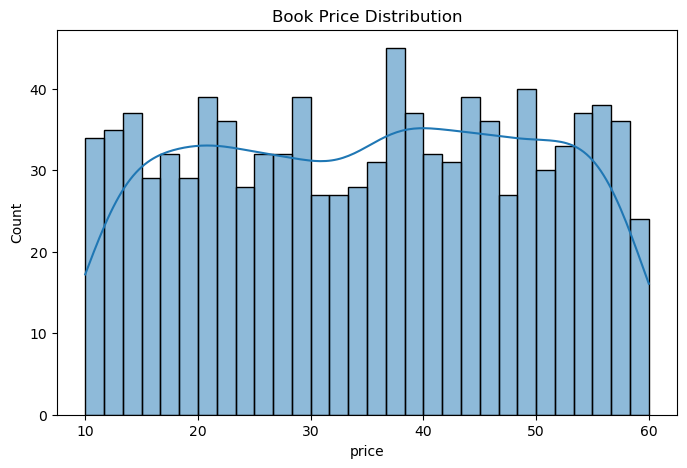

In [187]:
# Book Price Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    books["price"],
    bins=30,
    kde=True)

plt.title("Book Price Distribution")

plt.show()

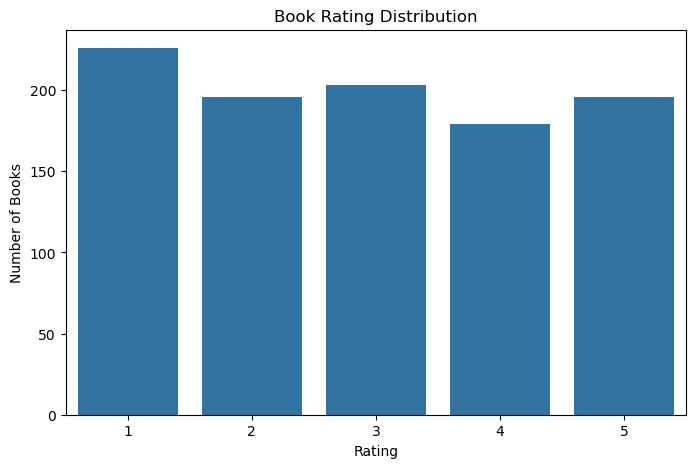

In [ ]:
# Rating Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=books,
    x="rating")

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()

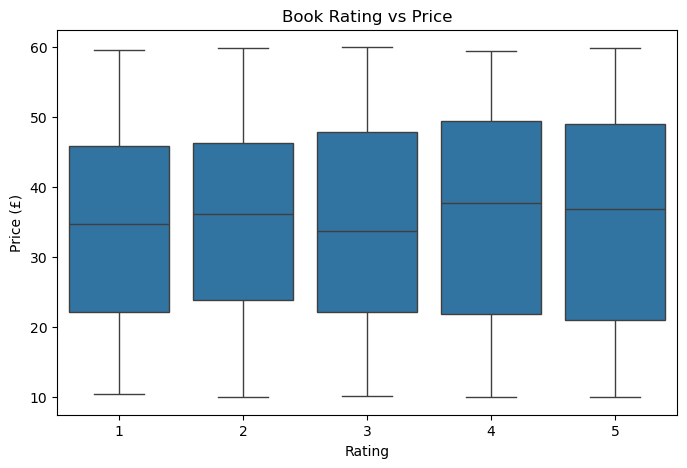

In [ ]:
# Rating vs Price
plt.figure(figsize=(8,5))

sns.boxplot(
    data=books,
    x="rating",
    y="price")

plt.title("Book Rating vs Price")
plt.xlabel("Rating")
plt.ylabel("Price (£)")

plt.show()

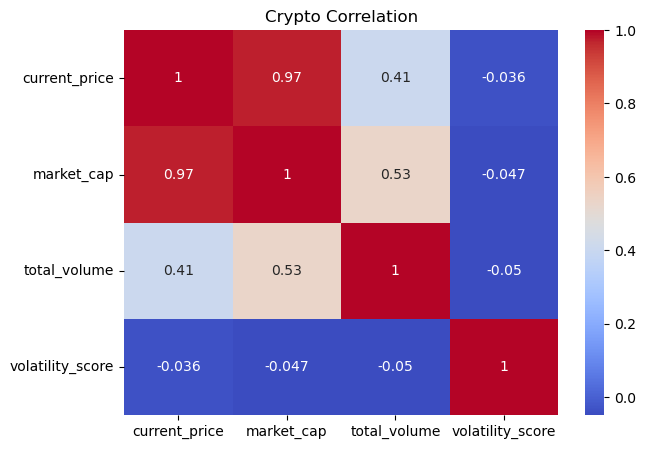

In [ ]:
# Crypto Correlation Heatmap
crypto_cols = [
    "current_price",
    "market_cap",
    "total_volume",
    "volatility_score"]

plt.figure(figsize=(7,5))

sns.heatmap(
    crypto[crypto_cols].corr(),
    annot=True,
    cmap="coolwarm")

plt.title("Crypto Correlation")

plt.show()

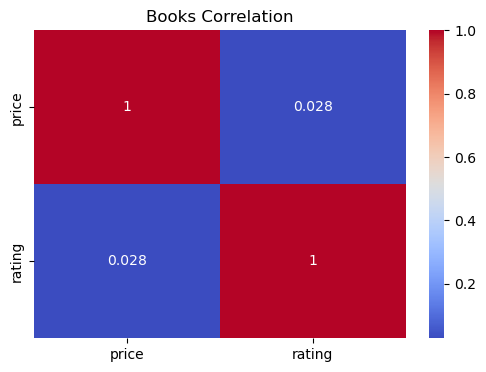

In [ ]:
# Books Correlation Heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    books[
        ["price", "rating"]
    ].corr(),
    annot=True,
    cmap="coolwarm")

plt.title("Books Correlation")

plt.show()

In [ ]:
# Insights
# Crypto Insights
print("Highest Market Cap Coin:")

print(
    crypto.loc[
        crypto["market_cap"].idxmax(),
        "name"])

print("\nMost Volatile Coin:")

print(
    crypto.loc[
        crypto["volatility_score"].idxmax(),
        "name"])

print("\nHighest Volume Coin:")

print(
    crypto.loc[
        crypto["total_volume"].idxmax(),
        "name"])

Highest Market Cap Coin:
Bitcoin

Most Volatile Coin:
Pons

Highest Volume Coin:
Tether


In [ ]:
# Books Insights
print("Average Book Price:")

print(
    round(
        books["price"].mean(),
        2))

print("\nAverage Price by Rating:")

print(
    books.groupby(
        "rating"
    )["price"].mean())

print("\nBooks by Rating:")

print(
    books["rating"].value_counts().sort_index())

Average Book Price:
35.07

Average Price by Rating:
rating
1    34.561195
2    34.810918
3    34.692020
4    36.093296
5    35.374490
Name: price, dtype: float64

Books by Rating:
rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64


In [194]:
# Summary of key insights
print(" SUMMARY OF KEY INSIGHTS")

print("\nCrypto Insights:")
print("- Large market-cap coins generally have higher trading volumes.")
print("- Smaller coins tend to show higher volatility.")
print("- Market cap and trading volume have a positive relationship.")
print("- Isolation Forest identified unusual crypto market observations.")

print("\nBooks Insights:")
print("- Book prices vary across low, medium and high price ranges.")
print("- Ratings range from 1 to 5.")
print("- Higher ratings do not necessarily mean higher book prices.")
print("- Most books are available in stock.")

print("\nOverall Insight:")
print("- API and web-scraped data can be cleaned and analyzed using the same EDA workflow.")

 SUMMARY OF KEY INSIGHTS

Crypto Insights:
- Large market-cap coins generally have higher trading volumes.
- Smaller coins tend to show higher volatility.
- Market cap and trading volume have a positive relationship.
- Isolation Forest identified unusual crypto market observations.

Books Insights:
- Book prices vary across low, medium and high price ranges.
- Ratings range from 1 to 5.
- Higher ratings do not necessarily mean higher book prices.
- Most books are available in stock.

Overall Insight:
- API and web-scraped data can be cleaned and analyzed using the same EDA workflow.


In [ ]:
# Save Cleaned Data
# Export CSV Files
crypto.to_csv(
    "crypto_cleaned.csv",
    index=False)

books.to_csv(
    "books_cleaned.csv",
    index=False)

print("Files saved successfully.")

Files saved successfully.


In [ ]:
# Reusable cleaning functions / class
class DataCleaner:

    def clean_crypto(self, df):
        df = df.copy()
        df = df.drop_duplicates(subset="id")
        df = df[df["current_price"] > 0]

        df["market_cap"] = df["market_cap"].fillna(
            df["market_cap"].median())

        df["total_volume"] = df["total_volume"].fillna(
            df["total_volume"].median())

        return df


    def clean_books(self, df):
        df = df.copy()

        df["title"] = df["title"].str.strip()

        df = df.drop_duplicates(
            subset="title")

        df = df.dropna(
            subset=["title", "price", "rating"])

        return df


cleaner = DataCleaner()

crypto_clean = cleaner.clean_crypto(crypto)
books_clean = cleaner.clean_books(books)

print("Reusable cleaning completed.")
print("Crypto shape:", crypto_clean.shape)
print("Books shape:", books_clean.shape)

Reusable cleaning completed.
Crypto shape: (100, 16)
Books shape: (999, 6)
